# **Exploratory Data Analysis**
This notebook explores the unified document dataset to gain an understanding of the dataset as well as its implications for the rest of the pipeline

## Load Dataset + Verify Project Files

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

project_path = Path("/content/drive/MyDrive/newstart_ai")

print("Exists:", project_path.exists())

print("\nContents:")
for item in project_path.iterdir():
    print(item)

Exists: True

Contents:
/content/drive/MyDrive/newstart_ai/data


In [ ]:
processed_path = Path(
    "/content/drive/MyDrive/newstart_ai/data/processed"
)

print("Processed folder exists:", processed_path.exists())

print("\nFiles:")
for file in processed_path.iterdir():
    print(file.name)

Processed folder exists: True

Files:
final_dataset.csv
final_metadata.csv


In [ ]:
import pandas as pd

dataset_path = (
    "/content/drive/MyDrive/newstart_ai/data/processed/final_dataset.csv"
)

df = pd.read_csv(dataset_path)

print("Dataset loaded!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded!
Rows: 754
Columns: 12


In [ ]:
df.columns.tolist()

['document_id',
 'filename',
 'filepath',
 'agency',
 'form_number',
 'document_type',
 'url',
 'file_exists',
 'text',
 'page_count',
 'text_length',
 'extraction_success']

In [ ]:
df.head(3)

,document_id,filename,filepath,agency,form_number,document_type,url,file_exists,text,page_count,text_length,extraction_success
0,1,i-765ws.pdf,/content/drive/MyDrive/newstart_ai/data/raw/us...,USCIS,I-765,form,NaN,True,Form I-765 Worksheet USCIS\nForm I-765WS\nDepa...,1,1281,True
1,2,i-361instr.pdf,/content/drive/MyDrive/newstart_ai/data/raw/us...,USCIS,I-361,instructions,NaN,True,Instructions for Affidavit of\nFinancial Suppo...,6,17876,True
2,3,i-508instr.pdf,/content/drive/MyDrive/newstart_ai/data/raw/us...,USCIS,I-508,instructions,NaN,True,"Instructions for Waiver of Certain Rights,\nPr...",4,9966,True


## Dataset Overview
It helps to have a high level overview of the data like the available features, data types, and any missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   document_id         754 non-null    int64 
 1   filename            754 non-null    object
 2   filepath            754 non-null    object
 3   agency              754 non-null    object
 4   form_number         452 non-null    object
 5   document_type       754 non-null    object
 6   url                 23 non-null     object
 7   file_exists         754 non-null    bool  
 8   text                754 non-null    object
 9   page_count          754 non-null    int64 
 10  text_length         754 non-null    int64 
 11  extraction_success  754 non-null    bool  
dtypes: bool(2), int64(3), object(7)
memory usage: 60.5+ KB


In [ ]:
df.isnull().sum()

,0
document_id,0
filename,0
filepath,0
agency,0
form_number,302
document_type,0
url,731
file_exists,0
text,0
page_count,0


## Agency Distribution
The first check was verifying that all four agencies are represented in the final dataset.
Balanced representation is important because highly imbalanced datasets can bias machine learning models toward the larger classes.

In [ ]:
agency_counts = df["agency"].value_counts()

agency_counts

,count
agency,
DMV,277
USCIS,256
SSA,198
IRS,23


In [ ]:
agency_percent = (
    df["agency"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

agency_percent

,proportion
agency,
DMV,36.74
USCIS,33.95
SSA,26.26
IRS,3.05


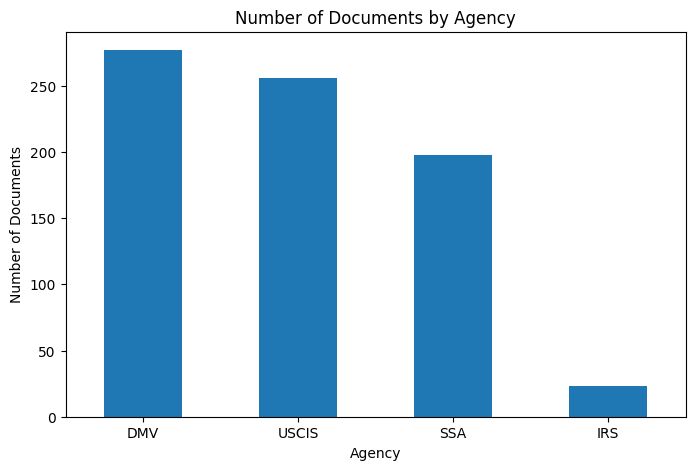

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

agency_counts.plot(
    kind="bar"
)

plt.title("Number of Documents by Agency")
plt.xlabel("Agency")
plt.ylabel("Number of Documents")

plt.xticks(rotation=0)

plt.show()

The bar chart shows the distribution of documents collected from each government agency. While the dataset contains documents from all four target agencies, the classes are not perfectly balanced. DMV and USCIS contribute the largest number of documents, followed by SSA, while IRS contributes substantially fewer documents.

This imbalance is due to differences in the number of publicly available forms maintained by each agency rather than the data collection process itself. For example, the IRS portion of this project focused on primary tax forms and instructions, resulting in a smaller but more targeted collection.

Understanding this class distribution is important before model development because class imbalance can influence classifier performance. If left unaddressed, a model may become biased toward agencies with more training examples. These results suggest that class balancing techniques or evaluation metrics beyond overall accuracy (such as precision, recall, and F1-score) should be considered during model evaluation.

In [ ]:
df["text_length"].describe()

,text_length
count,754.000000
mean,15094.352785
std,28958.520523
min,112.000000
25%,3773.250000
50%,7638.000000
75%,19048.000000
max,630280.000000


In [ ]:
text_stats = (
    df.groupby("agency")["text_length"]
    .describe()
    .round(2)
)

text_stats

,count,mean,std,min,25%,50%,75%,max
agency,,,,,,,,
DMV,277.0,4479.60,4009.33,112.0,1900.00,3355.0,5694.00,34643.0
IRS,23.0,63052.17,131830.19,3326.0,8913.50,23338.0,49248.50,630280.0
SSA,198.0,10875.40,7137.05,1749.0,5306.25,7724.5,16433.75,41135.0
USCIS,256.0,25534.23,21612.79,665.0,11162.50,21327.5,31791.00,148353.0


## Document Length Distribution

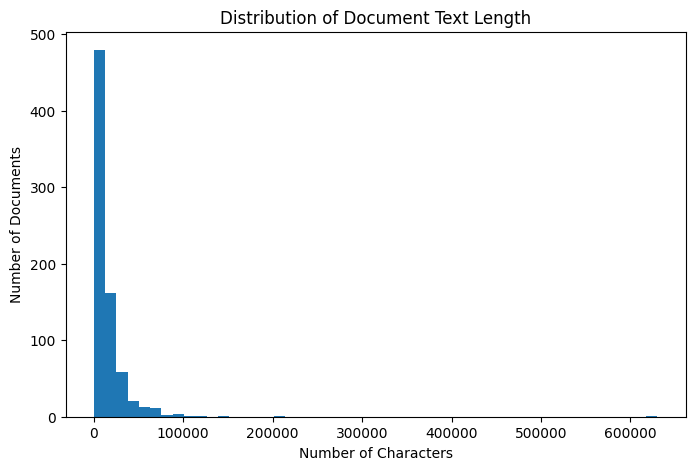

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["text_length"],
    bins=50
)

plt.title("Distribution of Document Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Documents")

plt.show()

The distribution of document text lengths is highly skewed to the right, with the majority of documents containing relatively short amounts of text and a small number of documents containing substantially more content. Most documents fall within the lower end of the text length range, while a handful of exceptionally long documents create a long tail extending to over 600,000 characters.

This is expected for government documents, as many forms consist of only a few pages with fields to complete, while others include lengthy instructions, policy guidance, or supplemental materials. The presence of these large documents highlights the considerable variation in document size across the dataset.

Understanding this distribution is important before model development because many natural language processing models have maximum input length limits. The results suggest that preprocessing strategies such as truncation, chunking, or document summarization may be necessary for unusually large documents.

## Text Length by Agency
Comparing the text length with the agency shows whether certain agencies had longer or shorter documents

<Figure size 800x500 with 0 Axes>

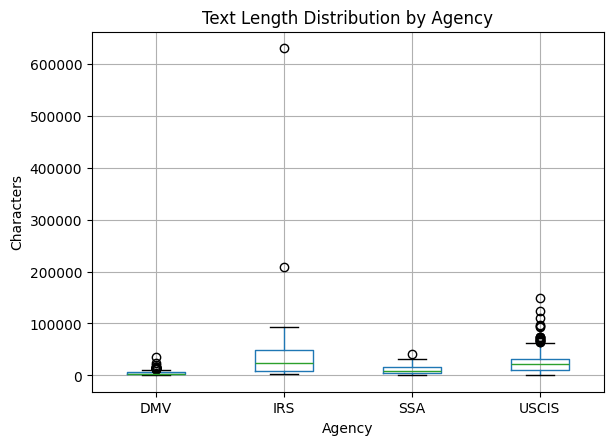

In [ ]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="text_length",
    by="agency"
)

plt.title("Text Length Distribution by Agency")
plt.suptitle("")
plt.xlabel("Agency")
plt.ylabel("Characters")

plt.show()

<Figure size 800x500 with 0 Axes>

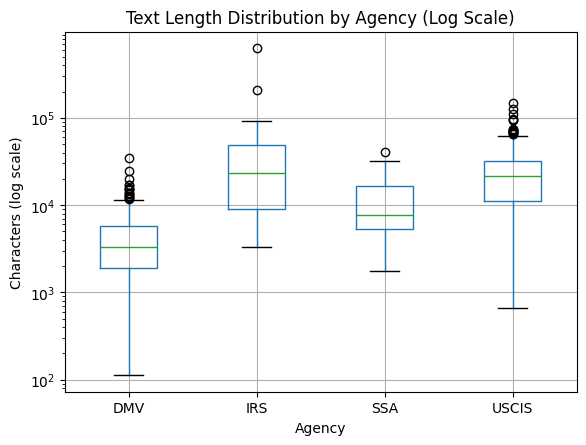

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(
    column="text_length",
    by="agency"
)

plt.yscale("log")

plt.title("Text Length Distribution by Agency (Log Scale)")
plt.suptitle("")
plt.xlabel("Agency")
plt.ylabel("Characters (log scale)")

plt.show()

In [ ]:
df.nlargest(
    10,
    "text_length"
)[
    [
        "filename",
        "agency",
        "text_length",
        "page_count"
    ]
]

,filename,agency,text_length,page_count
738,i1040gi.pdf,IRS,630280,126
736,iw2w3.pdf,IRS,208134,36
190,i-485instr.pdf,USCIS,148353,42
29,i-129instr.pdf,USCIS,124786,32
82,i-131instr.pdf,USCIS,111091,30
201,n-400instr.pdf,USCIS,96119,29
112,i-765instr.pdf,USCIS,95094,25
85,g-1055.pdf,USCIS,93302,57
735,i941.pdf,IRS,92938,17
742,iw7.pdf,IRS,84371,16


## Text Cleaning for Word Frequency Analysis
Before analyzing the vocabulary, the extracted document text is cleaned by converting the text to lowercase, removing punctuation and numbers, removing common english stop words, removing short words."

In [ ]:
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Stop words loaded:", len(stop_words))

Stop words loaded: 198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_text(text):
    """
    Clean extracted PDF text for word frequency analysis
    """

    # lowercase
    text = text.lower()

    # remove non alphabetic characters
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    # tokenize
    words = text.split()

    # remove stop words and short words
    words = [
        word
        for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    return words

In [ ]:
sample = df.iloc[0]["text"]

clean_text(sample)[:20]

['form',
 'worksheet',
 'uscis',
 'form',
 'department',
 'homeland',
 'security',
 'omb',
 'citizenship',
 'immigration',
 'services',
 'expires',
 'applying',
 'employment',
 'authorization',
 'deferred',
 'action',
 'consideration',
 'deferred',
 'action']

In [ ]:
df["clean_words"] = df["text"].apply(clean_text)

df[
    [
        "agency",
        "clean_words"
    ]
].head()

,agency,clean_words
0,USCIS,"[form, worksheet, uscis, form, department, hom..."
1,USCIS,"[instructions, affidavit, financial, support, ..."
2,USCIS,"[instructions, waiver, certain, rights, privil..."
3,USCIS,"[instructions, request, certificate, non, exis..."
4,USCIS,"[nonimmigrant, petition, based, blanket, petit..."


In [ ]:
def get_top_words(dataframe, agency, n=20):

    words = (
        dataframe[
            dataframe["agency"] == agency
        ]["clean_words"]
        .explode()
    )

    counts = Counter(words)

    return counts.most_common(n)

In [ ]:
get_top_words(
    df,
    "USCIS",
    20
)

[('form', 10030),
 ('number', 9610),
 ('information', 8934),
 ('name', 8007),
 ('uscis', 7923),
 ('part', 5182),
 ('may', 4557),
 ('application', 4174),
 ('provide', 4054),
 ('item', 4049),
 ('must', 3723),
 ('states', 3381),
 ('united', 3364),
 ('date', 3227),
 ('signature', 3019),
 ('address', 2831),
 ('petition', 2830),
 ('page', 2827),
 ('instructions', 2707),
 ('request', 2512)]

In [ ]:
custom_stopwords = {
    "form",
    "number",
    "information",
    "name",
    "page",
    "part",
    "item",
    "date",
    "address",
    "signature",
    "provide",
    "must",
    "may",
    "request",
    "states",
    "united"
}

stop_words.update(custom_stopwords)

print("Total stop words:", len(stop_words))

Total stop words: 214


In [ ]:
df["clean_words"] = df["text"].apply(clean_text)

In [ ]:
get_top_words(
    df,
    "USCIS",
    20
)

[('uscis', 7923),
 ('application', 4174),
 ('petition', 2830),
 ('instructions', 2707),
 ('submit', 2465),
 ('status', 2402),
 ('evidence', 2392),
 ('immigration', 2384),
 ('section', 2380),
 ('complete', 2271),
 ('yes', 2254),
 ('filing', 2083),
 ('file', 1923),
 ('additional', 1888),
 ('country', 1821),
 ('yyyy', 1800),
 ('interpreter', 1793),
 ('applicant', 1764),
 ('family', 1744),
 ('contact', 1729)]

In [ ]:
agencies = df["agency"].unique()

for agency in agencies:
    print("="*60)
    print(agency)
    print("="*60)

    top_words = get_top_words(
        df,
        agency,
        20
    )

    for word, count in top_words:
        print(f"{word}: {count}")

    print()

USCIS
uscis: 7923
application: 4174
petition: 2830
instructions: 2707
submit: 2465
status: 2402
evidence: 2392
immigration: 2384
section: 2380
complete: 2271
yes: 2254
filing: 2083
file: 1923
additional: 1888
country: 1821
yyyy: 1800
interpreter: 1793
applicant: 1764
family: 1744
contact: 1729

DMV
vehicle: 1673
state: 1406
code: 1219
dmv: 1131
section: 1129
california: 1126
license: 1019
driver: 815
department: 681
vehicles: 633
motor: 632
city: 629
www: 543
zip: 540
true: 524
owner: 507
business: 504
application: 483
rev: 460
program: 449

SSA
social: 3170
security: 2881
ssa: 1960
yes: 1534
que: 1321
act: 1081
del: 1014
para: 1008
use: 999
por: 921
benefits: 899
los: 851
federal: 750
child: 748
section: 713
person: 671
seguro: 661
records: 660
privacy: 645
informaci: 635

IRS
tax: 2559
line: 1663
return: 1209
see: 1197
income: 1104
amount: 1070
irs: 1035
box: 1018
enter: 916
filing: 856
instructions: 705
forms: 703
file: 703
credit: 660
year: 621
child: 590
section: 580
use: 577
empl

In [ ]:
import matplotlib.pyplot as plt


def plot_top_words(agency, n=15):

    words = get_top_words(
        df,
        agency,
        n
    )

    words_df = pd.DataFrame(
        words,
        columns=["word", "count"]
    )

    words_df = words_df.sort_values(
        "count"
    )

    plt.figure(figsize=(8,5))

    plt.barh(
        words_df["word"],
        words_df["count"]
    )

    plt.title(
        f"Top {n} Words in {agency} Documents"
    )

    plt.xlabel(
        "Frequency"
    )

    plt.ylabel(
        "Word"
    )

    plt.show()

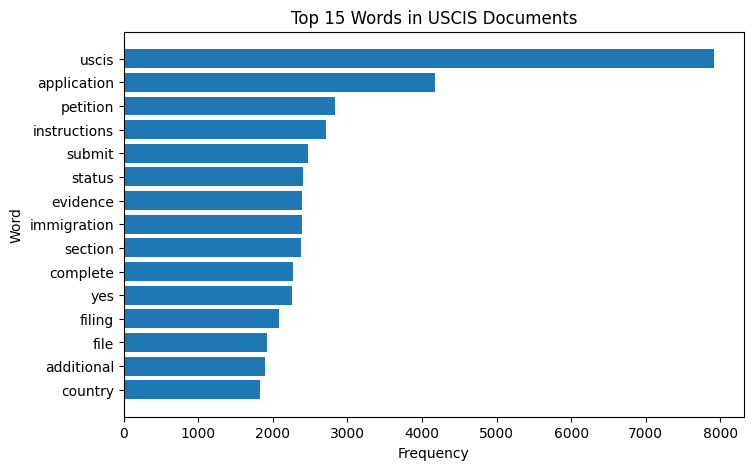

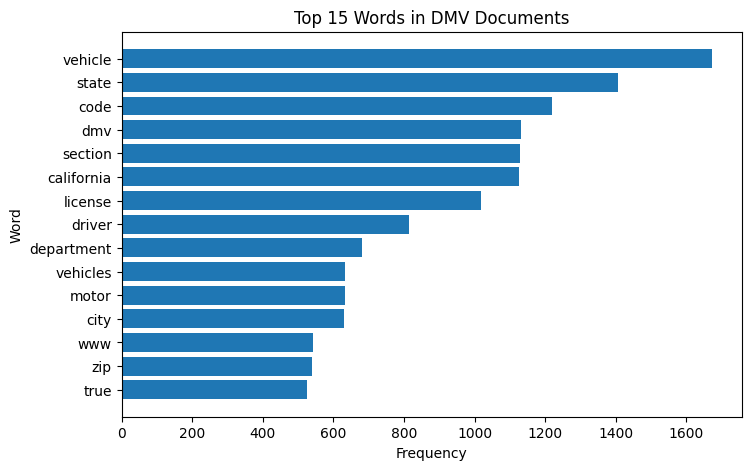

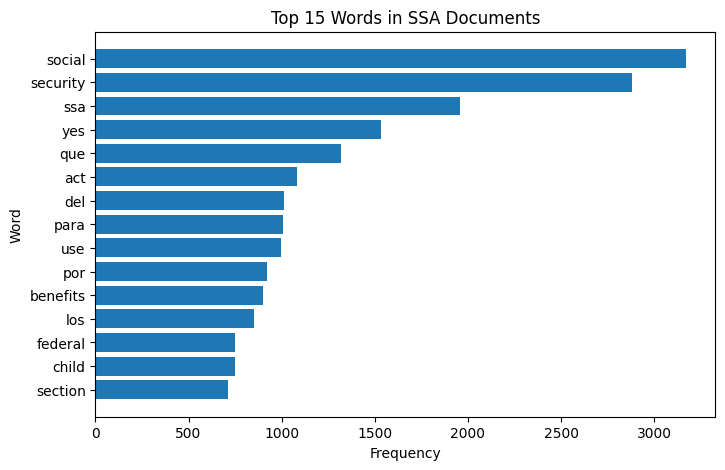

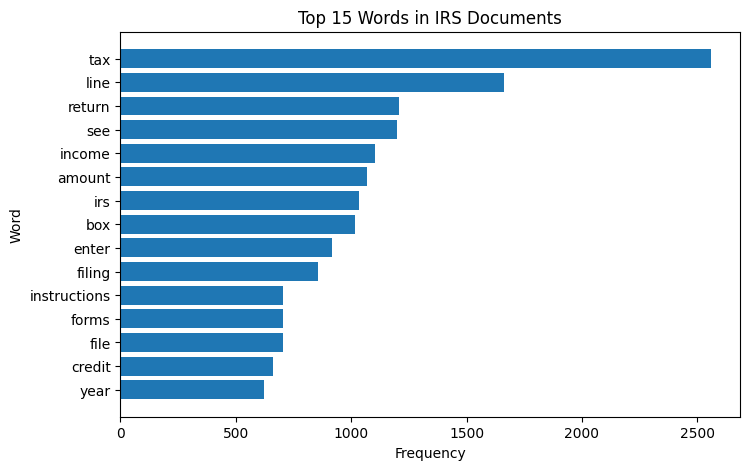

In [ ]:
for agency in ["USCIS", "DMV", "SSA", "IRS"]:
    plot_top_words(
        agency,
        15
    )

The horizontal bar chart shows the most frequently occurring words within each agency category. The results show that each agency has a distinct vocabulary pattern that reflects the types of documents and services associated with that organization.

USCIS: The most common words are strongly related to immigration and application processes, with terms such as application, petition, instructions, submit, status, evidence, and filing appearing frequently. This suggests that USCIS documents primarily focus on immigration forms, application requirements, and supporting documentation.

DMV: The most frequent terms are centered around vehicle and driver-related services, including vehicle, license, driver, department, motor, and state. The presence of terms such as California and code suggests many documents involve state specific motor vehicle regulations, licensing, and registration processes.

SSA: The dominant words reflect services related to social security, with frequent terms such as social, security, benefits, federal, child, and act. The presence of Spanish terms such as que, del, para, and los indicates that some SSA documents may contain bilingual content or translated forms. This becomes important for later in the pipeline as most were supposed to be filtered out.

IRS: The most frequent terms are closely associated with tax documents and filing procedures. Words such as tax, return, income, amount, filing, credit, forms, and instructions indicate that IRS documents primarily involve tax reporting, financial information, and compliance requirements.

Overall, the word frequency analysis shows that each agency has a unique terminology profile. These differences may mean that textual features such as word frequency and vocabulary patterns could be useful for distinguishing between document categories in the classification model.

In [ ]:
agency_summary = (
    df.groupby("agency")
    .agg(
        document_count=("document_id", "count"),
        avg_text_length=("text_length", "mean"),
        median_text_length=("text_length", "median"),
        avg_pages=("page_count", "mean"),
        extraction_success_rate=("extraction_success", "mean")
    )
    .round(2)
)

agency_summary

,document_count,avg_text_length,median_text_length,avg_pages,extraction_success_rate
agency,,,,,
DMV,277,4479.60,3355.0,1.79,1.0
IRS,23,63052.17,23338.0,12.26,1.0
SSA,198,10875.40,7724.5,4.76,1.0
USCIS,256,25534.23,21327.5,9.59,1.0


## Dataset Quality Assessment

In [ ]:
health_check = pd.DataFrame({
    "Metric": [
        "Total Documents",
        "Agencies",
        "Successful Extractions",
        "Failed Extractions",
        "Average Text Length",
        "Documents With Missing Text"
    ],
    "Value": [
        len(df),
        df["agency"].nunique(),
        df["extraction_success"].sum(),
        len(df) - df["extraction_success"].sum(),
        round(df["text_length"].mean(), 2),
        df["text"].isna().sum()
    ]
})

health_check

,Metric,Value
0,Total Documents,754.00
1,Agencies,4.00
2,Successful Extractions,754.00
3,Failed Extractions,0.00
4,Average Text Length,15094.35
5,Documents With Missing Text,0.00
